In [1]:
# Imports

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import matplotlib.patches as patches
from sklearn import metrics
from scipy.spatial import distance
from mpl_toolkits.mplot3d import Axes3D
import statsmodels.api as sm
from statsmodels.formula.api import ols
import pingouin as pg
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
pd.options.mode.chained_assignment = None  # default='warn'

In [2]:
# LIB: Base

task = "Task"
shovel = "Shovel"
cube = "Cube"

condition_key = "Condition"
c_0 = "C0"
c_1 = "C1"
c_2 = "C2"
p_0 = "P0"
p_1 = "P1"
p_2 = "P2"
conditions = [c_0, c_1, c_2, p_0, p_1, p_2]

#colors = ['tab:green', 'tab:orange', 'tab:red', 'tab:blue', 'tab:purple', 'tab:brown']
#colors = ["#FFD600", "#FF6D00", "#D50000", "#2962FF", "#AA00FF", "#C51162"]
colors = ["#00C853", "#FFD600", "#FF6D00", "#2962FF", "#AA00FF", "#D50000"]
#colors = ['tab:green', 'tab:yellow', 'tab:orange', 'tab:blue', 'tab:purple', 'tab:red']
#colors = ["#4CAF50", "#FFD600", "#FF6D00", "#2962FF", "#AA00FF", "#D50000"]

device_key = "Device"
device_proxy = "P"
device_controller = "C"
devices = [device_controller, device_proxy]

scaling_key = "Scaling"
scaling_none = "0"
scaling_subtle = "1"
scaling_pronounced = "2"
scalings = [scaling_none, scaling_subtle, scaling_pronounced]

device_x_scaling_key = "Device * Scaling"

subject_key = "Subject"

def get_confidence_interval(values):
    return 1.96 * stats.sem(values)

In [3]:
# LIB: Measurements

cohort = [
    #LS1
    "1_AlDe",
    "2_ReDo",
    "3_JuRo",
    "4_MaPo",
    "5_MaGo",
    "6_ElHa",
    #LS2
    "7_KlMe",
    "8_JuUe",
    "9_PhBa",
    "10_ToBa",
    "11_SePe",
    "12_ViDi",
    #LS3
    "13_FaPu",
    "14_JeBi",
    "15_DaEi",
    "16_MaEg",
    "17_JaDe",
    "18_InHo",
    #LS4
    "19_ToGr",
    "20_PeBu",
    "21_HaPr",
    "22_ClSt",
    "23_DaMe",
    "24_JoHi",
    #LS5
    "25_LeSc",
    "26_BaBa",
    "27_KaHi",
    "28_JoSc",
    "29_JeHo",
    "30_LiPa",
    #LS6
    "31_GiDe",
    "32_AnRa",
    "33_MaSu",
    "34_MiDo",
    "35_FlRu",
    "36_FaAs",
    #LS7
    "37_SiMi",
    "38_FaUe",
    "39_JeOb",
    "40_HeSe",
    "41_AnOb",
    "42_StSp",
    ]

hmd = "hmd"

unity = "u"
imot = "i"

start_ts = "start"
end_ts = "end"

unity_unix_key = "ts_unix_ms"

unified_delta_key = "delta_ms"
unified_unix_key = "unix_ms"

imot_unix_key = "System Timestamp CAL"
imot_delta_ms_key = "Timestamp"
hr_key = 'Heart rate'
gsr_res_key = 'GSR Resistance CAL'
gsr_con_key = 'GSR Conductance CAL'
imot_keys = [imot_unix_key, imot_delta_ms_key, hr_key, gsr_res_key, gsr_con_key]

baseline_ms = 30_000

def get_df(p, e, c, s):
    path = './data/' + p + '/'  + s  + '_' + e + '_' + c + '.csv'
    return pd.read_csv(path)

def task_start(df, e):
    #return df[unity_unix_key].min()
    if e == cube:
        return df[unity_unix_key].min()
    else:
        first_load = df[(df["collision_or_load_count"] == 1)]
        return first_load[unity_unix_key].min()

def task_end(df, e):
    #return df[unity_unix_key].max()
    if e == cube:
        return df[unity_unix_key].max()
    else:
        final_load = df[(df["collision_or_load_count"] == 20)]
        final_unload = final_load[(final_load["shovel_loaded_state"] == False)]

        return final_unload[unity_unix_key].min()
    
def trim_df(df, min_ts, max_ts):
    min_trimmed = df[(df[unified_unix_key] >= min_ts)]
    full_trimmed = min_trimmed[(min_trimmed[unified_unix_key] <= max_ts)]
    return full_trimmed

def calc_pt_deltas(unity_df, pt):
    unity_df[pt + "_x_delta"] = unity_df[pt + "_x"].diff()
    unity_df[pt + "_y_delta"] = unity_df[pt + "_y"].diff()
    unity_df[pt + "_z_delta"] = unity_df[pt + "_z"].diff()

    new_df = unity_df.dropna(subset = [pt + "_x_delta", pt + "_y_delta", pt + "_z_delta"])

    new_df[pt+"_delta_dist"] = new_df.apply(lambda x: distance.euclidean((x[pt + "_x_delta"], x[pt + "_y_delta"], x[pt + "_z_delta"]), (0,0,0)), axis = 1)
    new_df[pt+"_delta_dist_planar"] = new_df.apply(lambda x: distance.euclidean((x[pt + "_x_delta"], x[pt + "_z_delta"]), (0,0)), axis = 1)
    new_df[pt+"_delta_dist_vertical"] = new_df.apply(lambda x: abs(x[pt + "_y_delta"]), axis = 1) #TODO check if this makes sense

    return new_df

def get_pt_path_len(p, pt):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])
    return df[pt+"_delta_dist"].sum()

def get_pt_path_len_planar(p, pt):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])
    return df[pt+"_delta_dist_planar"].sum()

def get_pt_path_len_vertical(p, pt):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])
    return df[pt+"_delta_dist_vertical"].sum()

def sync_timestamps(unity_df, imot_df, e):
    task_start_ts = task_start(unity_df, e)

    unity_df[unified_unix_key] = unity_df[unity_unix_key]
    unity_df[unified_delta_key] = unity_df[unified_unix_key] - task_start_ts

    imot_start = imot_df.dropna(subset = imot_unix_key).iloc[0][imot_unix_key]

    imot_df[unified_unix_key] = imot_start + imot_df[imot_delta_ms_key]
    imot_df[unified_delta_key] = imot_df[unified_unix_key] - task_start_ts

    return [unity_df, imot_df]

def get_condition(p, e, c, augment_unity):
    imot_raw = get_df(p, e, c, imot).filter(items=imot_keys)
    unity_raw = get_df(p, e, c, unity)

    synced = sync_timestamps(unity_raw, imot_raw, e)
    unity_synced = synced[0]
    imot_synced = synced[1]

    # Add HMD path data
    if augment_unity:
        unity_synced = calc_pt_deltas(unity_synced, hmd)

    task_start_ts = task_start(unity_raw, e)
    task_end_ts = task_end(unity_raw, e)

    #imot_pre_task = trim_df(imot_synced, task_start_ts - baseline_ms, task_start_ts)
    #min_hr = imot_pre_task.dropna(subset = hr_key)[hr_key].quantile(extrema_quantile)
    #min_gsr_con = imot_pre_task.dropna(subset = gsr_con_key)[gsr_con_key].quantile(extrema_quantile)

    return {
        imot: imot_synced,
        unity: unity_synced,
        start_ts: task_start_ts,
        end_ts: task_end_ts,
        #"min_hr": min_hr,
        #"min_gsr_con": min_gsr_con
    }

def get_experiment(p, e, augment_unity):
    condition_data = list(map(lambda x: get_condition(p, e, x, augment_unity), conditions))

    #min_hr = np.min(list(map(lambda x: x["min_hr"], condition_data)))
    #min_gsr_con = np.min(list(map(lambda x: x["min_gsr_con"], condition_data)))

    return {
            c_0: condition_data[0],
            c_1: condition_data[1],
            c_2: condition_data[2],
            p_0: condition_data[3],
            p_1: condition_data[4],
            p_2: condition_data[5],
            #"min_hr": min_hr,
            #"min_gsr_con": min_gsr_con
    }
def get_participant(p, augment_unity):
    return {
        cube: get_experiment(p, cube, augment_unity),
        shovel: get_experiment(p, shovel, augment_unity),
        subject_key: p
    }

In [71]:
# Notebook Defs

def remove_timeseries_outliers(df, key):
    df = df.dropna(subset = key)
    return df[np.abs(stats.zscore(df[key])) < 3] if key != hr_key else df

def normalized_curve_comparison(data, ax, e, key, ylim, ylabel, polyfit = None, rolling = None):
    for i in range(len(conditions)):
        color = colors[i]
        normalized_curve(data, ax, e, conditions[i], key, ylim, ylabel, color, False, polyfit, rolling)


def normalized_curve(data, ax, e, c, key, ylim, ylabel, main_color = colors[3], show_individual = True, polyfit = None, rolling = None):
    participants = list(map(lambda x: x[e][c], data))

    dfs = []
    for p in participants:
        start = p[start_ts]
        end = p[end_ts]
        duration_ms = end - start

        df = trim_df(p[imot], min_ts = start, max_ts = end)
        df = remove_timeseries_outliers(df, key)
        df["percentage"] = (df[unified_delta_key] / duration_ms) * 100
        df = df.set_index("percentage", drop = False)
        dfs.append(df)

    ax.title.set_text(c)
    ax.set_ylim(ylim)
    ax.set_xlabel('Task Duration [%]')
    ax.set_ylabel(ylabel)
    ax.set_xlim([0,100])

    sample_pts = list(map(lambda x: x, range(0, 101, 1)))
    synced_samples = []
    for i in sample_pts:
        sample_values = []
        for df in dfs:
            iloc_idx = df.index.get_indexer([i], method='nearest')
            nearest_row = df.iloc[iloc_idx[0]]
            nearest_value = nearest_row[key]
            sample_values.append(nearest_value)
        synced_samples.append(sample_values)

    #Individual
    if show_individual:
        for i in range(len(participants)):
            participant_values = list(map(lambda x: x[i], synced_samples))
            ax.plot(sample_pts, participant_values, color="tab:orange", alpha= 0.1, lw=3)

    #Trend
    agg_values = list(map(lambda x: [np.mean(x), get_confidence_interval(x)], synced_samples))
    y_mean = list(map(lambda x: x[0], agg_values))
    y_top = list(map(lambda x: x[0] + x[1], agg_values))
    y_bottom = list(map(lambda x: x[0] - x[1], agg_values))
    ax.plot(sample_pts, y_mean, lw=2, color=main_color, alpha=1, label=c)
    ax.fill_between(sample_pts,y_bottom, y_top, color=main_color, alpha=0.2)

    #Polyfit
    if polyfit is not None:
        z = np.polyfit(sample_pts, y_mean, polyfit)
        p = np.poly1d(z)
        ax.plot(sample_pts, p(sample_pts), lw=2, color=main_color)
    elif rolling is not None:
        ax.plot(sample_pts, pd.Series(y_mean).rolling(rolling, min_periods=1).mean(), lw=2, color=main_color)
            

In [5]:
data = list(map(lambda x: get_participant(x, augment_unity=False), cohort))

print(data[0][subject_key])
print(data[len(data)-1][subject_key])
data[0][shovel][c_0][unity].head(3)

1_AlDe
42_StSp


,ts_datetime,ts_unix_ms,primary_grab_hand,pt_x,pt_y,pt_z,st_x,st_y,st_z,pv_x,...,hmd_z,ee_x,ee_y,ee_z,shovel_loaded_state,cube_max_target_reached,grab_count,collision_or_load_count,unix_ms,delta_ms
0,6/17/2025 12:47:46 PM,1750157266336,Right,0.013479,0.082617,0.009835,-0.026263,0.161040,0.275415,0.013534,...,0.109002,-0.000339,0.069995,0.740010,False,0,1,0,1750157266336,-7097
1,6/17/2025 12:47:46 PM,1750157266350,Right,0.013560,0.082527,0.009633,-0.025655,0.159465,0.275159,0.013639,...,0.108624,-0.109571,0.213849,0.729117,False,0,1,0,1750157266350,-7083
2,6/17/2025 12:47:46 PM,1750157266379,Right,0.013584,0.082218,0.009236,-0.025412,0.157989,0.274887,0.013584,...,0.107817,-0.109463,0.209042,0.729566,False,0,1,0,1750157266379,-7054


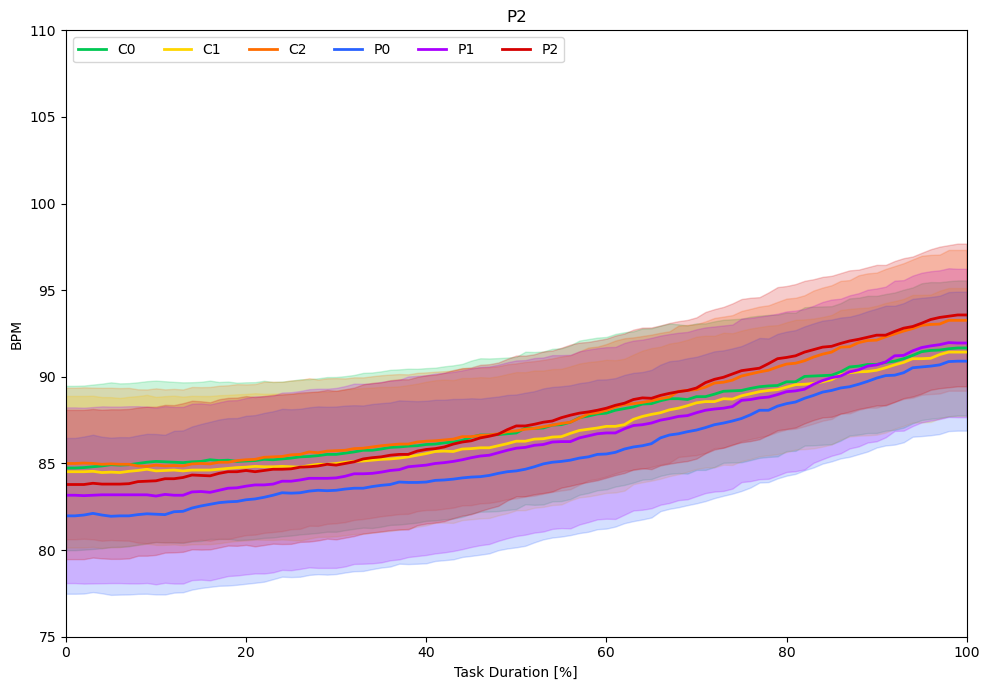

In [89]:
fig, ax = plt.subplots(1,1, figsize=(10, 7))
ylim = [75,110]
ylabel = 'BPM'
normalized_curve_comparison(data, ax, cube, hr_key, ylim, ylabel)
ax.legend(loc='upper left', ncols=6)
fig.tight_layout()
plt.show()

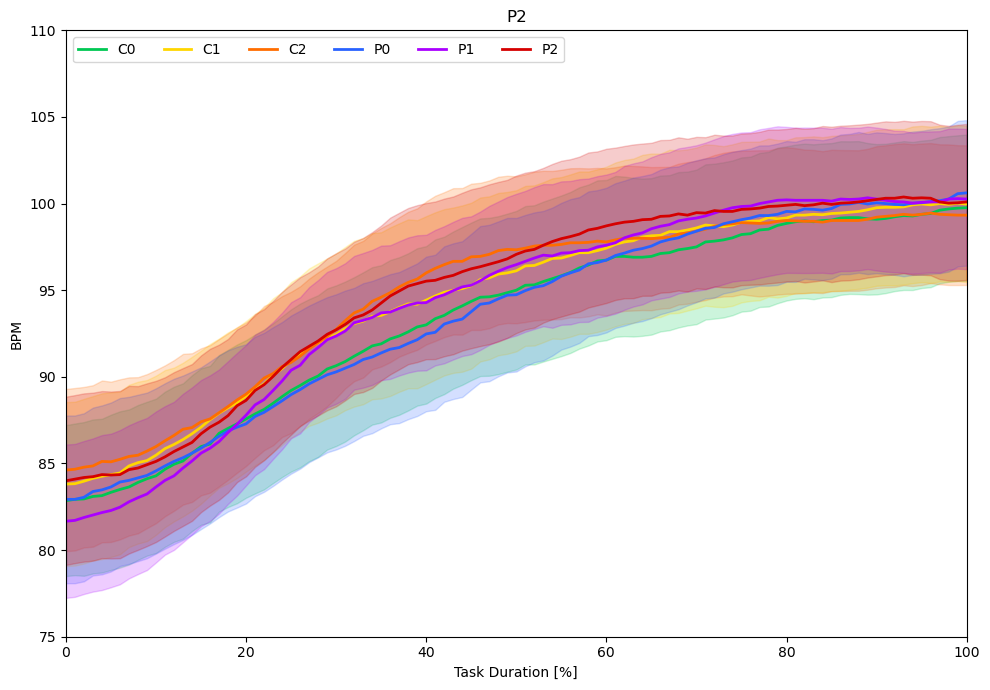

In [88]:
fig, ax = plt.subplots(1,1, figsize=(10, 7))
ylim = [75,110]
ylabel = 'BPM'
normalized_curve_comparison(data, ax, shovel, hr_key, ylim, ylabel)
ax.legend(loc='upper left', ncols=6)
fig.tight_layout()
plt.show()

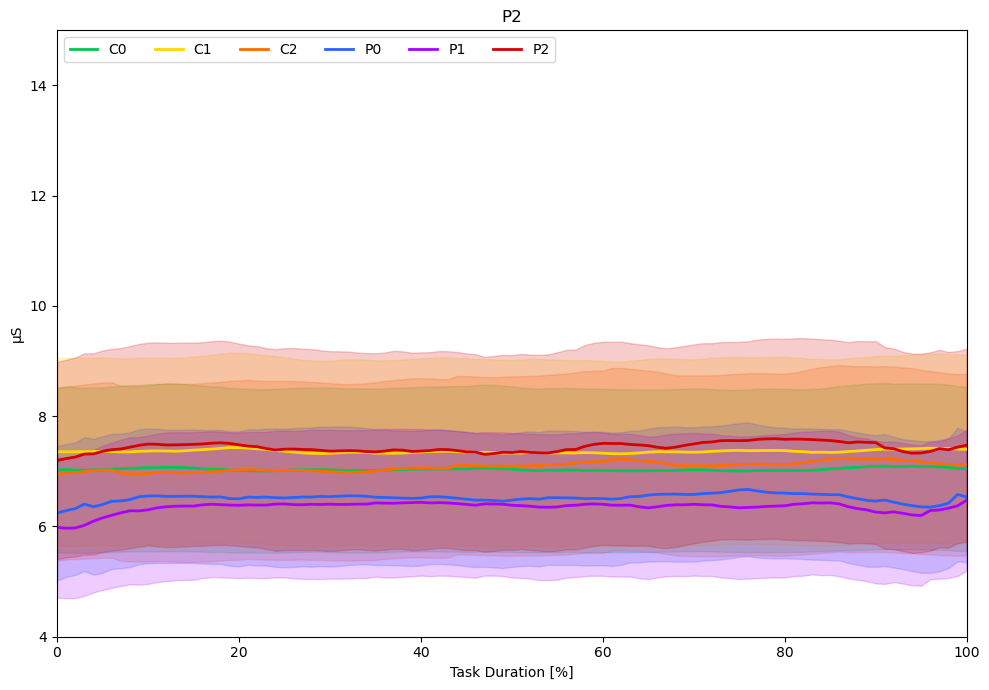

In [90]:
fig, ax = plt.subplots(1,1, figsize=(10, 7))
ylim = [4,15]
ylabel = 'µS'
normalized_curve_comparison(data, ax, cube, gsr_con_key, ylim, ylabel)
ax.legend(loc='upper left', ncols=6)
fig.tight_layout()
plt.show()

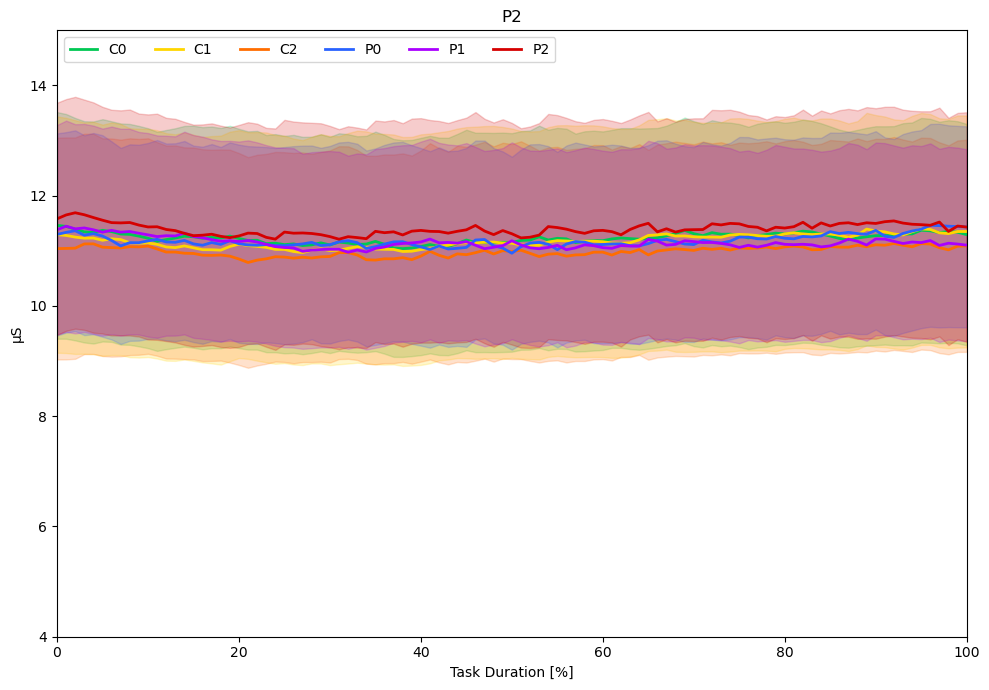

In [91]:
fig, ax = plt.subplots(1,1, figsize=(10, 7))
ylim = [4,15]
ylabel = 'µS'
normalized_curve_comparison(data, ax, shovel, gsr_con_key, ylim, ylabel)
ax.legend(loc='upper left', ncols=6)
fig.tight_layout()
plt.show()

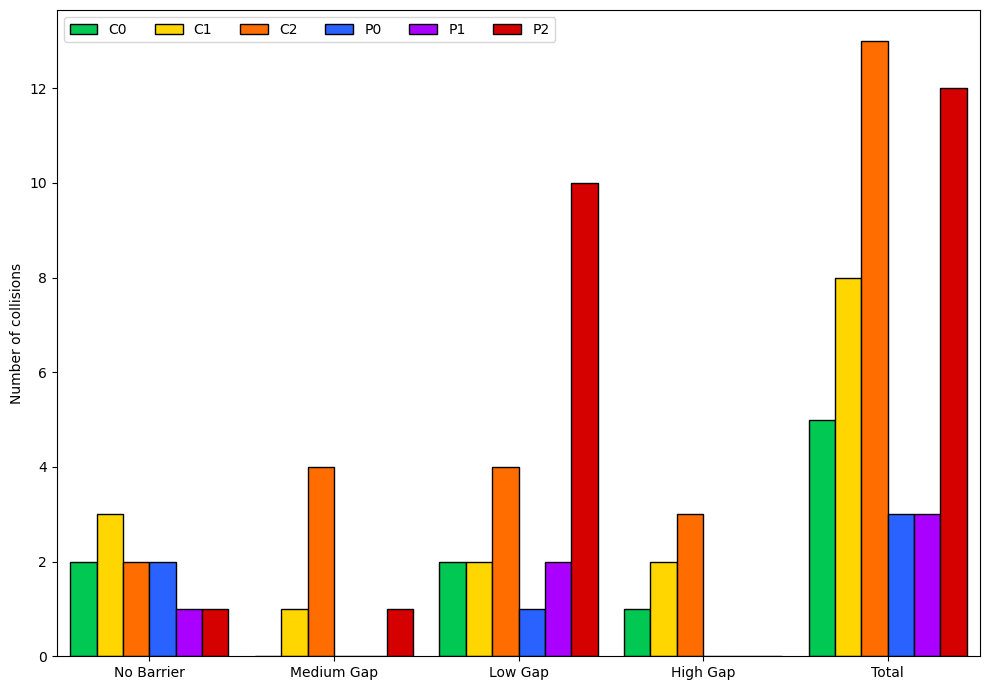

In [108]:
def single_collision_split(p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    first = df[(df["cube_max_target_reached"] == 1)]
    second = df[(df["cube_max_target_reached"] == 2)]
    third = df[(df["cube_max_target_reached"] == 3)]
    fourth = df[(df["cube_max_target_reached"] == 4)]

    first_collisons =first["collision_or_load_count"].max() - first["collision_or_load_count"].min()
    second_collisons =second["collision_or_load_count"].max() - second["collision_or_load_count"].min()
    third_collisons =third["collision_or_load_count"].max() - third["collision_or_load_count"].min()
    fourth_collisons =fourth["collision_or_load_count"].max() - fourth["collision_or_load_count"].min()

    return [first_collisons, second_collisons, third_collisons, fourth_collisons]

def get_cube_target_collisions(data):
    no_barrier = []
    medium_barrier = []
    low_barrier= []
    high_barrier = []
    total = []

    for c in conditions:
        participant_values = list(map(lambda x: x[cube][c], data))
        participant_splits = list(map(lambda x: single_collision_split(x), participant_values))

        p_no_barrier = list(map(lambda x: x[0],  participant_splits)) #No barrier is first target
        p_medium_barrier = list(map(lambda x: x[2],  participant_splits)) #Medium barrier is third taret (!)
        p_low_barrier = list(map(lambda x: x[1],  participant_splits)) #Low barrier is second target (!)
        p_high_barrier = list(map(lambda x: x[3],  participant_splits)) #High barrier is fourth target

        c_no_barrier = np.sum(p_no_barrier)
        no_barrier.append(c_no_barrier)

        c_medium_barrier = np.sum(p_medium_barrier)
        medium_barrier.append(c_medium_barrier)

        c_low_barrier = np.sum(p_low_barrier)
        low_barrier.append(c_low_barrier)

        c_high_barrier = np.sum(p_high_barrier)
        high_barrier.append(c_high_barrier)

        c_total = np.sum([c_no_barrier, c_medium_barrier, c_low_barrier, c_high_barrier])
        total.append(c_total)

    return [no_barrier, medium_barrier, low_barrier, high_barrier, total]

fig, ax = plt.subplots(1, 1, figsize=(10, 7))

splits_values = get_cube_target_collisions(data)
splits_labels = ["No Barrier", "Medium Gap", "Low Gap", "High Gap", "Total"]
column_labels = conditions
column_colors = colors
ylabel = "Number of collisions"

width = 1 / (len(column_labels)+1)  # the width of the bars
multiplier = 1
x = np.arange(len(splits_labels))  # the label locations
for i in range(len(column_labels)):
    values = list(map(lambda x: x[i], splits_values))
    offset = width * (multiplier)
    ax.bar(x + offset, values, width, color=column_colors[i], label=column_labels[i], edgecolor='black')
    multiplier += 1
ax.set_ylabel(ylabel)
ax.set_xticks(x+0.5, splits_labels)
ax.set_xlim([0, len(splits_labels)])
ax.legend(loc='upper left', ncols=6)
fig.tight_layout()
plt.show()

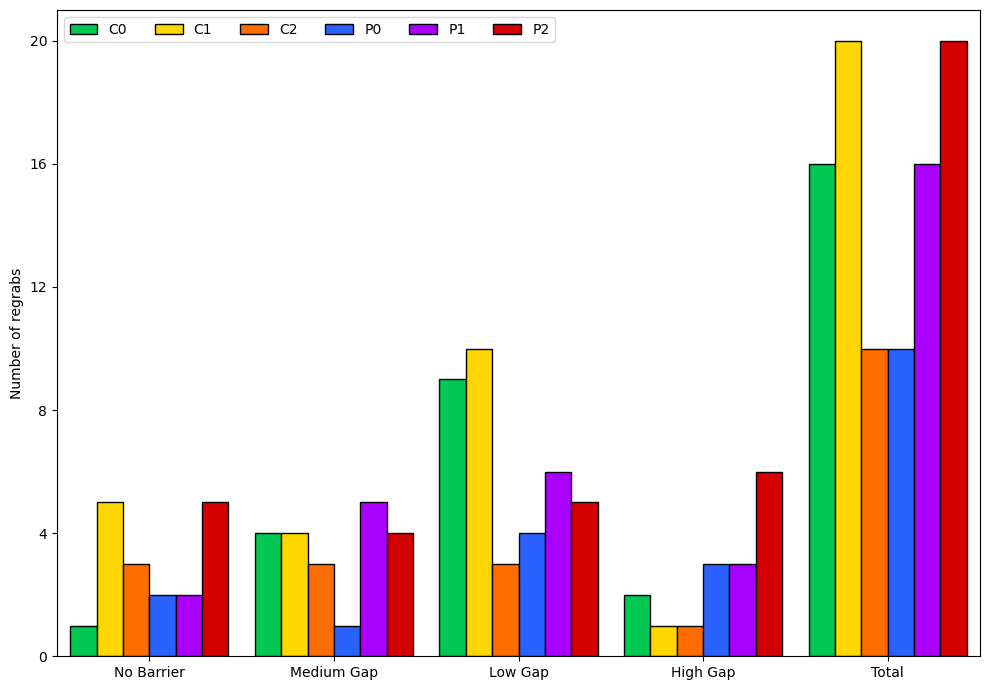

In [109]:
def single_grabcount_split(p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    first = df[(df["cube_max_target_reached"] == 1)]
    second = df[(df["cube_max_target_reached"] == 2)]
    third = df[(df["cube_max_target_reached"] == 3)]
    fourth = df[(df["cube_max_target_reached"] == 4)]

    first_regrabs =first["grab_count"].max() - first["grab_count"].min()
    second_regrabs =second["grab_count"].max() - second["grab_count"].min()
    third_regrabs =third["grab_count"].max() - third["grab_count"].min()
    fourth_regrabs =fourth["grab_count"].max() - fourth["grab_count"].min()

    return [first_regrabs, second_regrabs, third_regrabs, fourth_regrabs]

def get_cube_target_grabcount(data):
    no_barrier = []
    medium_barrier = []
    low_barrier= []
    high_barrier = []
    total = []

    for c in conditions:
        participant_values = list(map(lambda x: x[cube][c], data))
        participant_splits = list(map(lambda x: single_grabcount_split(x), participant_values))

        p_no_barrier = list(map(lambda x: x[0],  participant_splits)) #No barrier is first target
        p_medium_barrier = list(map(lambda x: x[2],  participant_splits)) #Medium barrier is third taret (!)
        p_low_barrier = list(map(lambda x: x[1],  participant_splits)) #Low barrier is second target (!)
        p_high_barrier = list(map(lambda x: x[3],  participant_splits)) #High barrier is fourth target

        c_no_barrier = np.sum(p_no_barrier)
        no_barrier.append(c_no_barrier)

        c_medium_barrier = np.sum(p_medium_barrier)
        medium_barrier.append(c_medium_barrier)

        c_low_barrier = np.sum(p_low_barrier)
        low_barrier.append(c_low_barrier)

        c_high_barrier = np.sum(p_high_barrier)
        high_barrier.append(c_high_barrier)

        c_total = np.sum([c_no_barrier, c_medium_barrier, c_low_barrier, c_high_barrier])
        total.append(c_total)

    return [no_barrier, medium_barrier, low_barrier, high_barrier, total]

fig, ax = plt.subplots(1, 1, figsize=(10, 7))

splits_values = get_cube_target_grabcount(data)
splits_labels = ["No Barrier", "Medium Gap", "Low Gap", "High Gap", "Total"]
column_labels = conditions
column_colors = colors
ylabel = "Number of regrabs"

width = 1 / (len(column_labels)+1)  # the width of the bars
multiplier = 1
x = np.arange(len(splits_labels))  # the label locations
for i in range(len(column_labels)):
    values = list(map(lambda x: x[i], splits_values))
    offset = width * (multiplier)
    ax.bar(x + offset, values, width, color=column_colors[i], label=column_labels[i], edgecolor='black')
    multiplier += 1
ax.set_ylabel(ylabel)
ax.set_xticks(x+0.5, splits_labels)
ax.set_xlim([0, len(splits_labels)])
ax.legend(loc='upper left', ncols=6)
ax.set_ylim([0,21])
ax.set_yticks([0, 4, 8, 12, 16, 20])

fig.tight_layout()
plt.show()

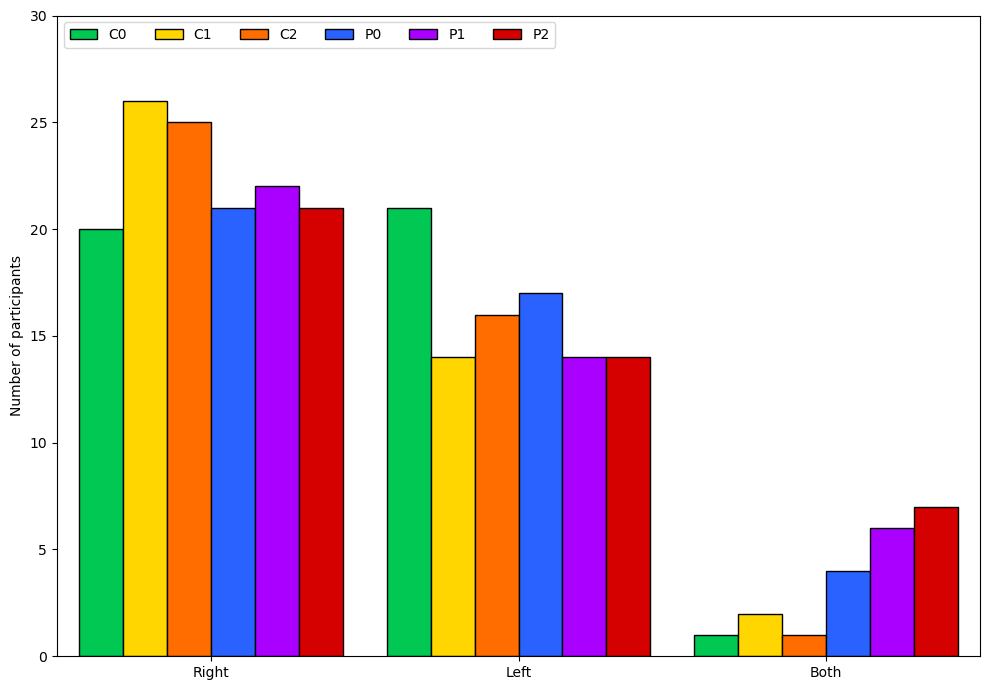

In [ ]:
primary_left = "Left"
primary_right = "Right"
primary_both = "Both"

primary_options = [primary_left, primary_right, primary_both]

def single_primary_hand(p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    left = (df['primary_grab_hand'] == primary_left).any()
    right = (df['primary_grab_hand'] == primary_right).any()

    if left & right:
        return primary_both
    elif left:
        return primary_left
    elif right:
        return primary_right
    else:
        raise "Error: No primary hand found"
    
def get_hand_splits(data, e):
    left = []
    right = []
    both= []

    for c in conditions:
        participant_values = list(map(lambda x: x[e][c], data))
        participant_splits = list(map(lambda x: single_primary_hand(x), participant_values))

        c_left = 0
        c_right = 0
        c_both = 0
        for hands in participant_splits:
            if hands == primary_left:
                c_left += 1
            elif hands == primary_right:
                c_right += 1
            elif hands == primary_both:
                c_both += 1
        left.append(c_left)
        right.append(c_right)
        both.append(c_both)

    return [right, left, both]

splits_labels = [primary_right, primary_left, primary_both]
column_labels = conditions
column_colors = colors
ylabel = "Number of participants"

fig, ax = plt.subplots(1, 1, figsize=(10, 7))
splits_values = get_hand_splits(data, cube)
width = 1 / (len(column_labels)+1)  # the width of the bars
multiplier = 1
x = np.arange(len(splits_labels))  # the label locations
for i in range(len(column_labels)):
    values = list(map(lambda x: x[i], splits_values))
    offset = width * (multiplier)
    ax.bar(x + offset, values, width, color=column_colors[i], label=column_labels[i], edgecolor='black')
    multiplier += 1
ax.set_ylabel(ylabel)
ax.set_xticks(x+0.5, splits_labels)
ax.set_xlim([0, len(splits_labels)])
ax.legend(loc='upper left', ncols=6)
ax.set_ylim([0,30])
# ax.set_yticks([0, 4, 8, 12, 16, 20])

fig.tight_layout()
plt.show()

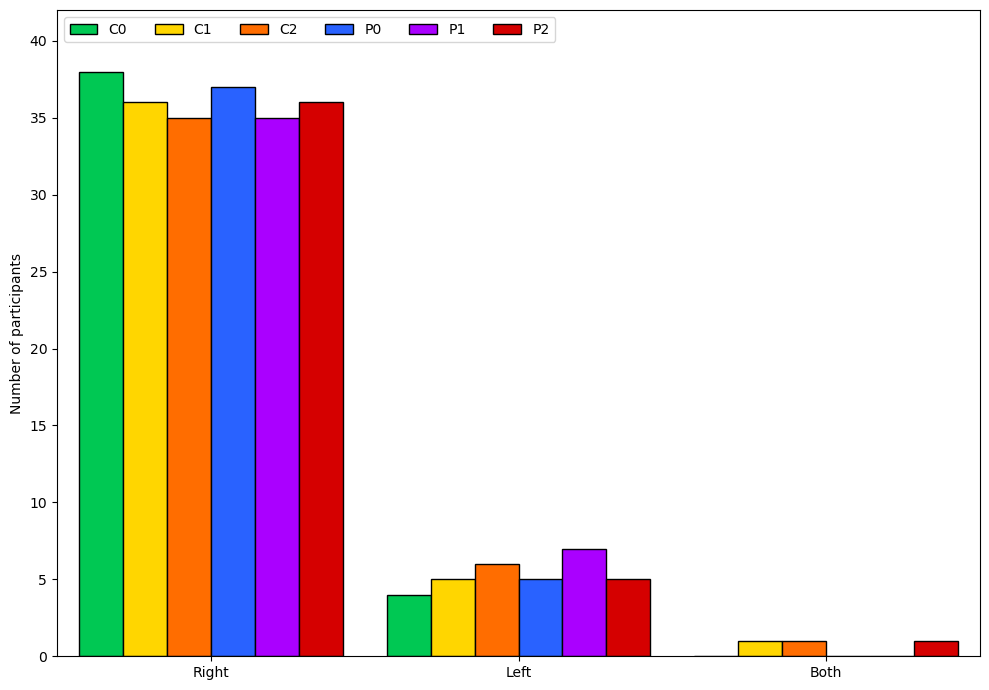

In [118]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
splits_values = get_hand_splits(data, shovel)
width = 1 / (len(column_labels)+1)  # the width of the bars
multiplier = 1
x = np.arange(len(splits_labels))  # the label locations
for i in range(len(column_labels)):
    values = list(map(lambda x: x[i], splits_values))
    offset = width * (multiplier)
    ax.bar(x + offset, values, width, color=column_colors[i], label=column_labels[i], edgecolor='black')
    multiplier += 1
ax.set_ylabel(ylabel)
ax.set_xticks(x+0.5, splits_labels)
ax.set_xlim([0, len(splits_labels)])
ax.legend(loc='upper left', ncols=6)
ax.set_ylim([0,42])
# ax.set_yticks([0, 4, 8, 12, 16, 20])

fig.tight_layout()
plt.show()

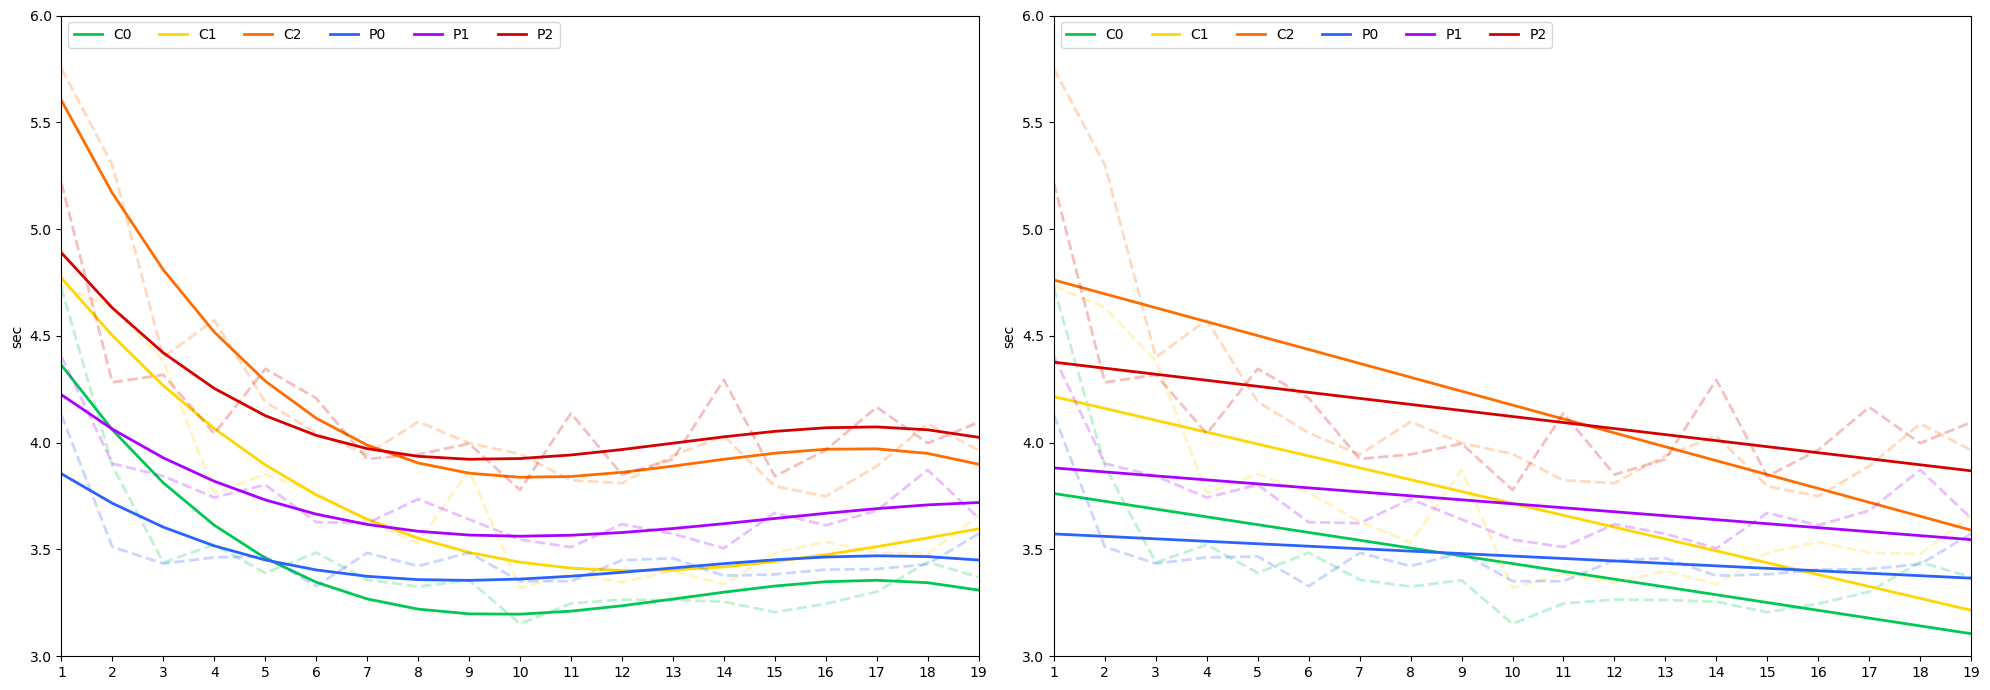

In [94]:
iterations = range(1, 20) # Exclude last iteration, as it is not complete (no return to pile)

def single_iteration_split (p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])
    iteration_times = []
    for i in iterations:
        iteration = df[(df["collision_or_load_count"] == i)]
        time = (iteration[unity_unix_key].max() - iteration[unity_unix_key].min())/ 1_000
        iteration_times.append(time)
    return iteration_times

def get_shovel_iteration_splits(data, c):
    participants = list(map(lambda x: x[shovel][c], data))
    participant_splits = list(map(lambda x: single_iteration_split(x), participants))
    condition_splits = []
    for i in range(len(iterations)):
        split = []
        for j in range(len(participants)):
            split.append(participant_splits[j][i])
        condition_splits.append(split)
    split_means = list(map(lambda x: np.mean(x), condition_splits))
    return split_means

splits = list(map(lambda x: get_shovel_iteration_splits(data, x), conditions))

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

for index in range(2):
    ax = axs[index]

    for i in range(len(conditions)):
        x = iterations
        y = splits[i]
        ax.plot(x, y, '--', lw=2, color=colors[i], alpha=0.25)
        z = np.polyfit(x, y, 3) if index == 0 else np.polyfit(x, y, 1)
        p = np.poly1d(z)
        ax.plot(x, p(x), lw=2, color=colors[i], label=conditions[i])

    ax.set_xticks(iterations)
    ax.set_xlim([1,19])
    ax.set_ylabel('sec')
    ax.set_ylim([3, 6])
    #ax.set_title('[Shovel] Full Iteration Splits')

    ax.legend(loc='upper left', ncols=6)

fig.tight_layout()
plt.show()

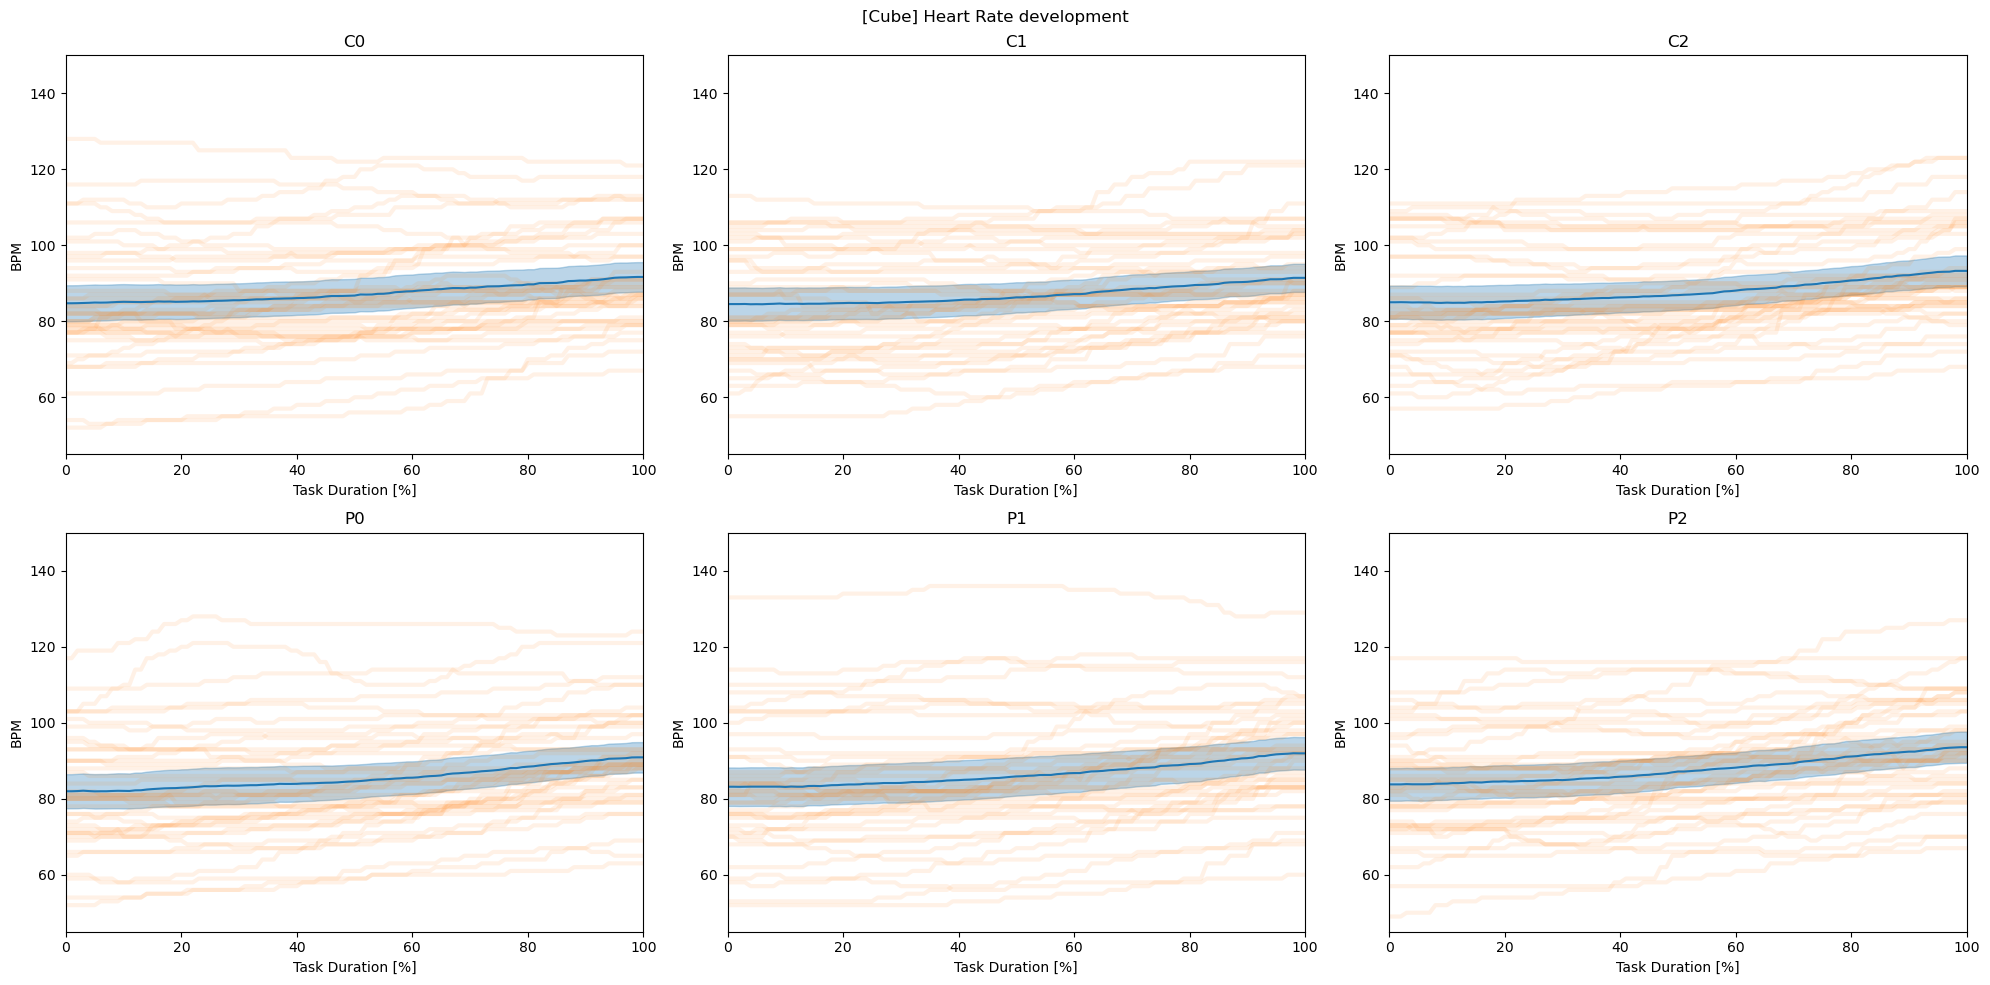

In [6]:
fig, axs = plt.subplots(2, 3, figsize=(20, 10))
ylim = [45,150]
ylabel = 'BPM'

plt.suptitle('[Cube] Heart Rate development')
normalized_curve(data, axs[0,0], cube, c_0, hr_key, ylim, ylabel)
normalized_curve(data, axs[0,1], cube, c_1, hr_key, ylim, ylabel)
normalized_curve(data, axs[0,2], cube, c_2, hr_key, ylim, ylabel)
normalized_curve(data, axs[1,0], cube, p_0, hr_key, ylim, ylabel)
normalized_curve(data, axs[1,1], cube, p_1, hr_key, ylim, ylabel)
normalized_curve(data, axs[1,2], cube, p_2, hr_key, ylim, ylabel)

fig.tight_layout()
plt.show()

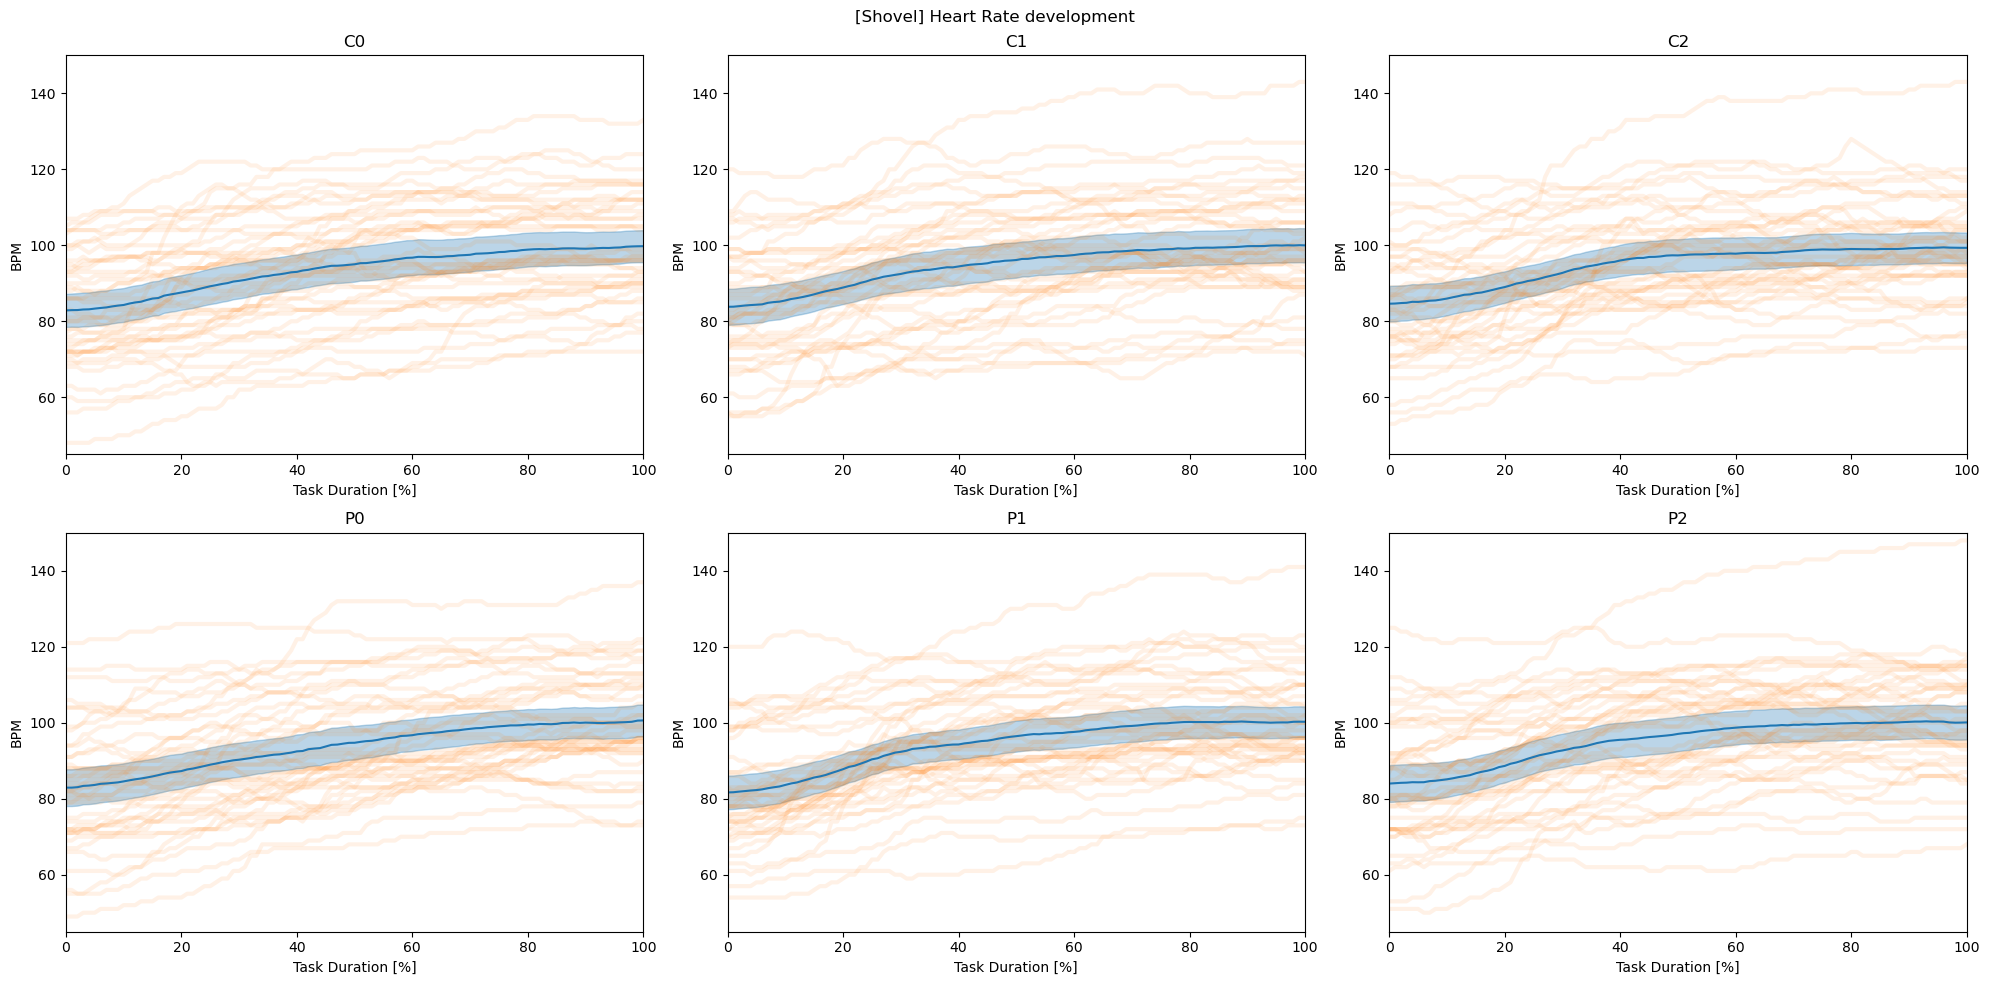

In [7]:
fig, axs = plt.subplots(2, 3, figsize=(20, 10))
ylim = [45,150]
ylabel = 'BPM'

plt.suptitle('[Shovel] Heart Rate development')
normalized_curve(data, axs[0,0], shovel, c_0, hr_key, ylim, ylabel)
normalized_curve(data, axs[0,1], shovel, c_1, hr_key, ylim, ylabel)
normalized_curve(data, axs[0,2], shovel, c_2, hr_key, ylim, ylabel)
normalized_curve(data, axs[1,0], shovel, p_0, hr_key, ylim, ylabel)
normalized_curve(data, axs[1,1], shovel, p_1, hr_key, ylim, ylabel)
normalized_curve(data, axs[1,2], shovel, p_2, hr_key, ylim, ylabel)

fig.tight_layout()
plt.show()

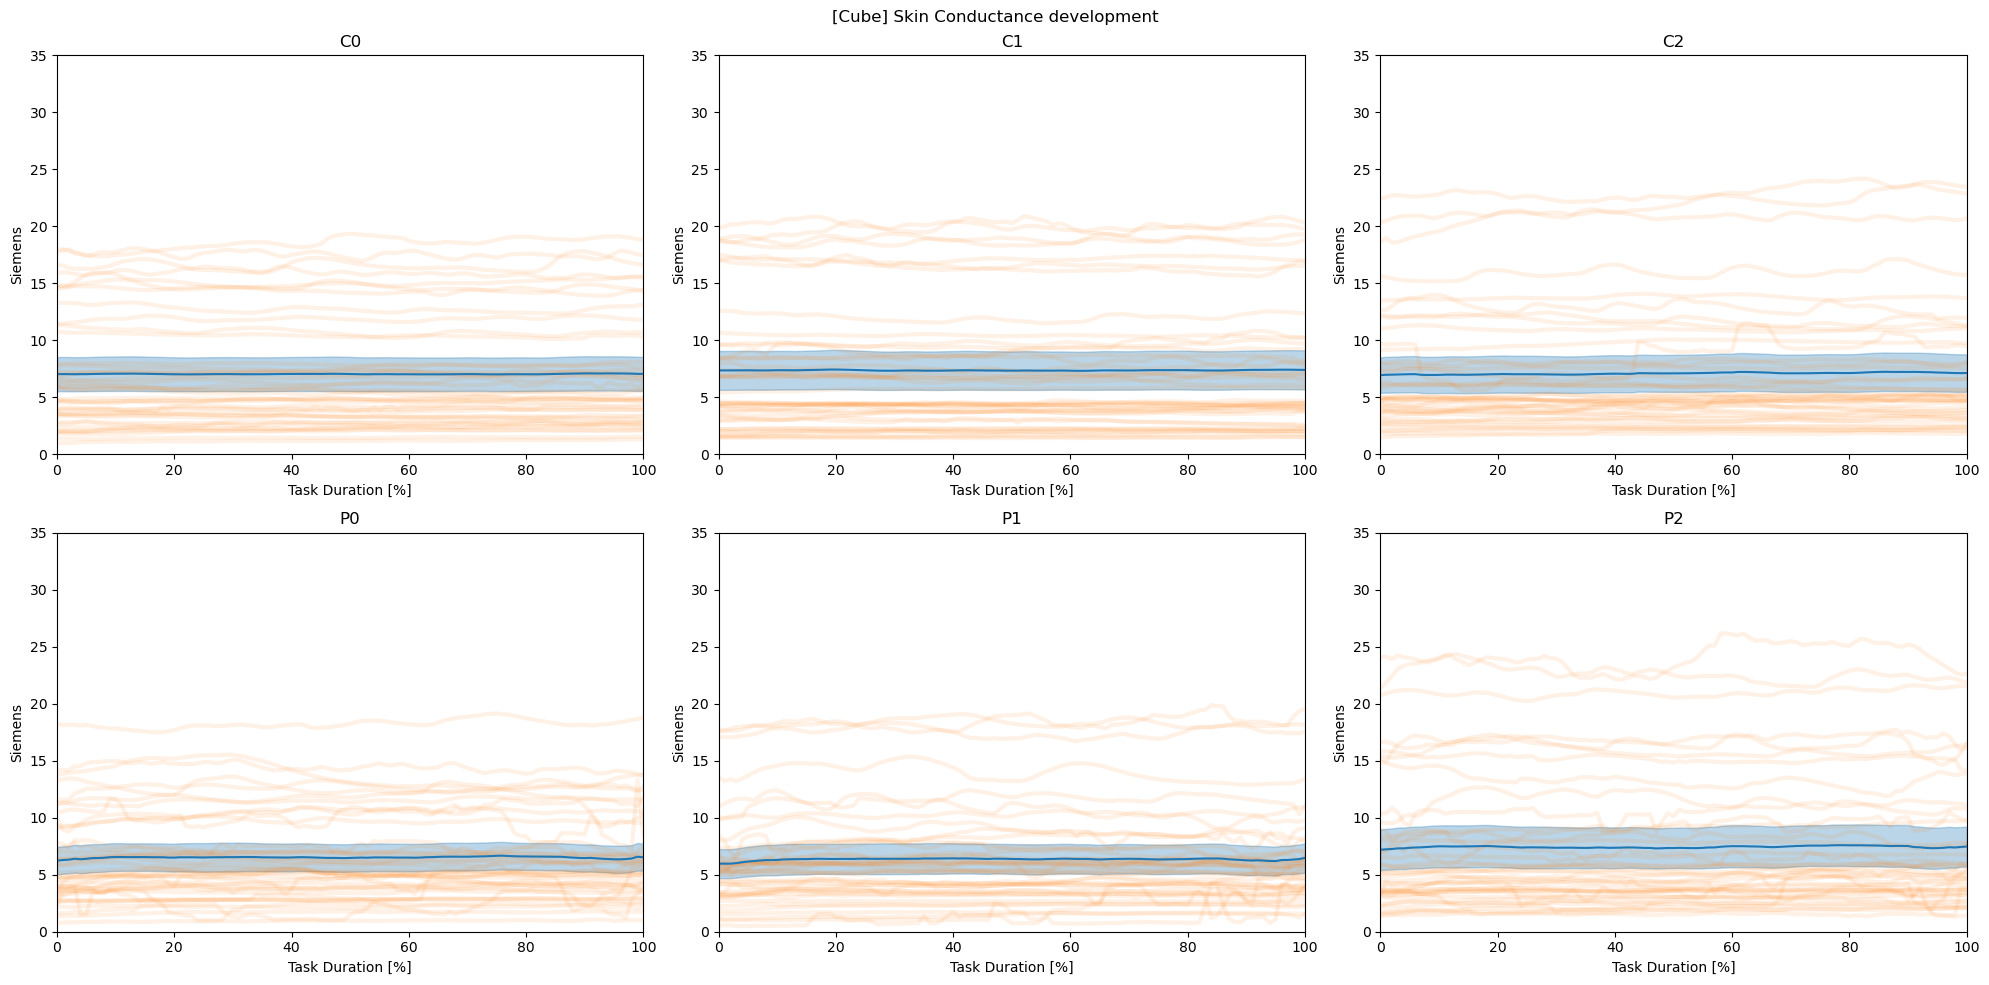

In [8]:
fig, axs = plt.subplots(2, 3, figsize=(20, 10))
ylim = [0,35]
ylabel = 'Siemens'

plt.suptitle('[Cube] Skin Conductance development')
normalized_curve(data, axs[0,0], cube, c_0, gsr_con_key, ylim, ylabel)
normalized_curve(data, axs[0,1], cube, c_1, gsr_con_key, ylim, ylabel)
normalized_curve(data, axs[0,2], cube, c_2, gsr_con_key, ylim, ylabel)
normalized_curve(data, axs[1,0], cube, p_0, gsr_con_key, ylim, ylabel)
normalized_curve(data, axs[1,1], cube, p_1, gsr_con_key, ylim, ylabel)
normalized_curve(data, axs[1,2], cube, p_2, gsr_con_key, ylim, ylabel)

fig.tight_layout()
plt.show()

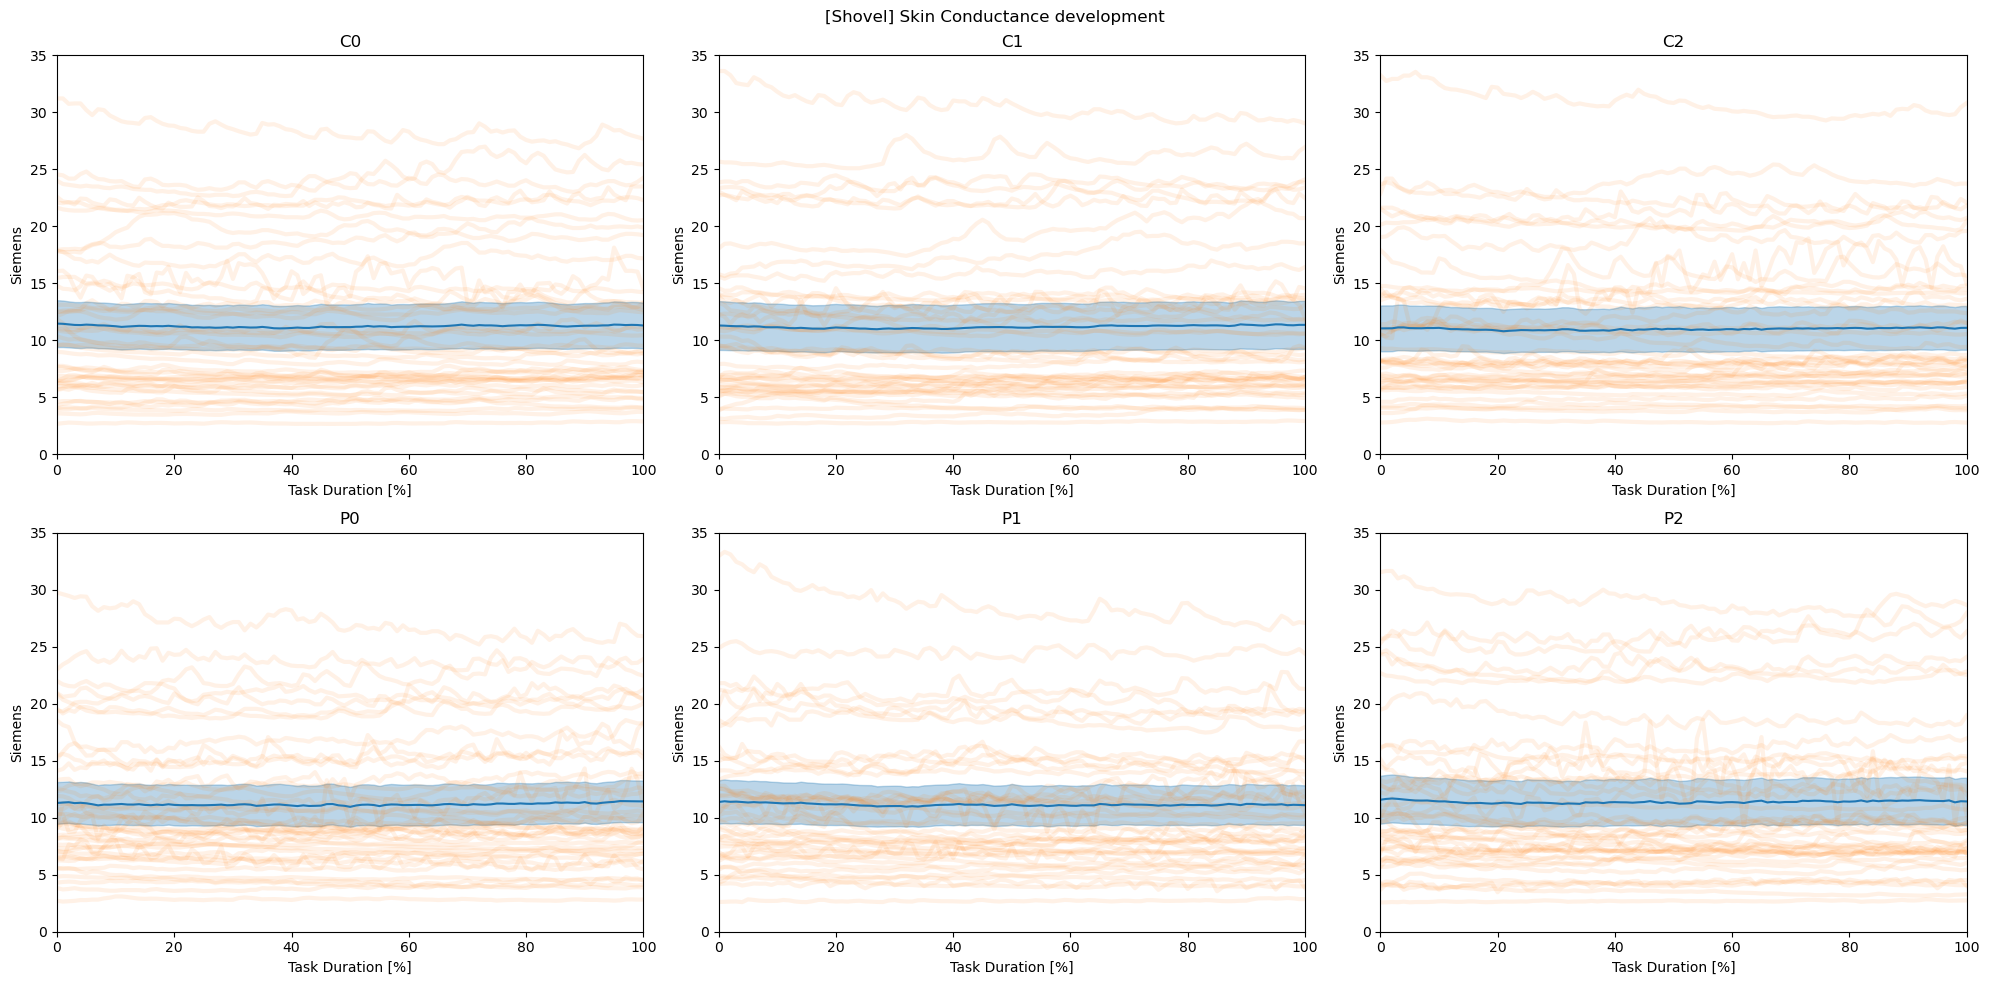

In [9]:
fig, axs = plt.subplots(2, 3, figsize=(20, 10))
ylim = [0,35]
ylabel = 'Siemens'

plt.suptitle('[Shovel] Skin Conductance development')
normalized_curve(data, axs[0,0], shovel, c_0, gsr_con_key, ylim, ylabel)
normalized_curve(data, axs[0,1], shovel, c_1, gsr_con_key, ylim, ylabel)
normalized_curve(data, axs[0,2], shovel, c_2, gsr_con_key, ylim, ylabel)
normalized_curve(data, axs[1,0], shovel, p_0, gsr_con_key, ylim, ylabel)
normalized_curve(data, axs[1,1], shovel, p_1, gsr_con_key, ylim, ylabel)
normalized_curve(data, axs[1,2], shovel, p_2, gsr_con_key, ylim, ylabel)

fig.tight_layout()
plt.show()

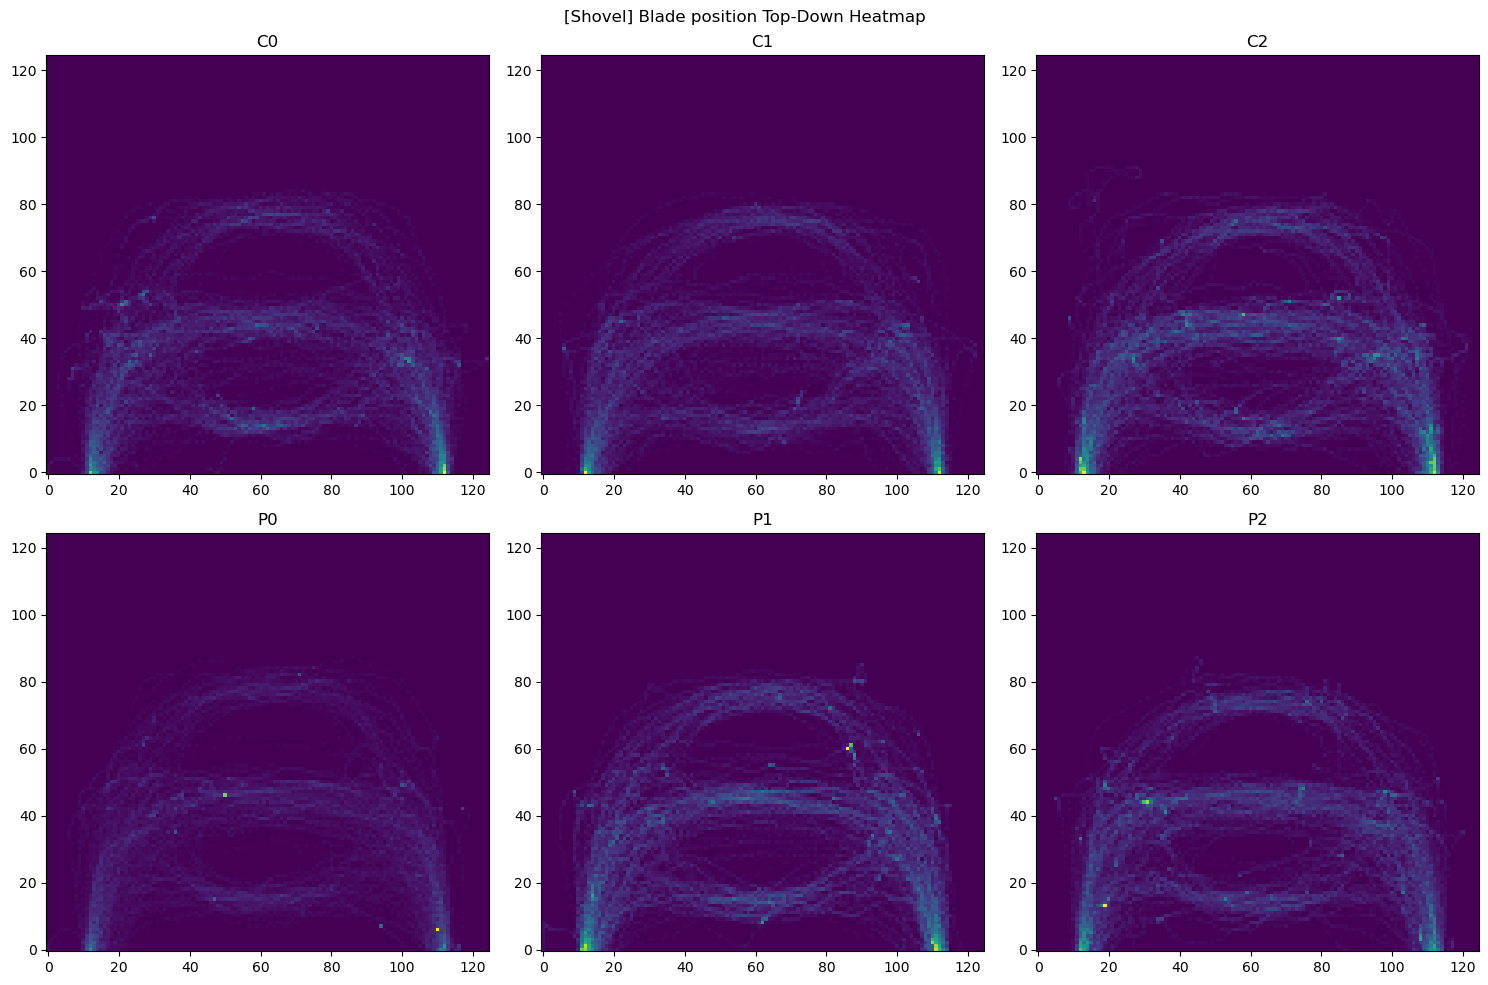

In [ ]:
end_effector = 'ee'
primary_tracked = 'pt'
primary_visible = 'pv'
secondary_tracked = 'st'
secondary_visible = 'sv'
hmd = 'hmd'

tracking_pts = [end_effector]

def mirror_x(df, pt):
    key = pt + '_x'
    df[key] = df.apply(lambda x: -x[key] if x['primary_grab_hand'] == 'Left' else x[key], axis = 1)

def rectify_unity (p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    for pt in tracking_pts:
        mirror_x(df, pt)

    return df

def top_heatmap(data, ax, e, c, pt):
    participants = list(map(lambda x: x[e][c], data))

    dfs = list(map(lambda x: rectify_unity(x), participants))
    all_values = pd.concat(dfs).sort_values(by=unified_delta_key)

    all_values = all_values[all_values[pt + "_y"] > 0.25]

    min_x = -1.25
    max_x = 1.25

    min_y = 0.25
    max_y = 2.25

    #forward = list(all_values[pt + "_z"])
    lateral = np.clip(list(all_values[pt + "_x"]), min_x, max_x)
    vertical = np.clip(list(all_values[pt + "_y"]), min_y, max_y)

    lateral = np.append(lateral, [min_x, max_x])
    vertical = np.append(vertical, [min_y, max_y])

    heatmap, xedges, yedges = np.histogram2d(lateral, vertical, bins=125)

    ax.title.set_text(c)
    ax.imshow(heatmap.T, origin='lower', cmap='viridis', aspect='auto')


fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.suptitle('[Shovel] Blade position Top-Down Heatmap')

shovel_tip = 'ee'
secondary_hand = 'st'
primary_hand = 'pt'

top_heatmap(data, axs[0,0], cube, c_0, end_effector)
top_heatmap(data, axs[0,1], cube, c_1, end_effector)
top_heatmap(data, axs[0,2], cube, c_2, end_effector)
top_heatmap(data, axs[1,0], cube, p_0, end_effector)
top_heatmap(data, axs[1,1], cube, p_1, end_effector)
top_heatmap(data, axs[1,2], cube, p_2, end_effector)

plt.tight_layout()
plt.show()

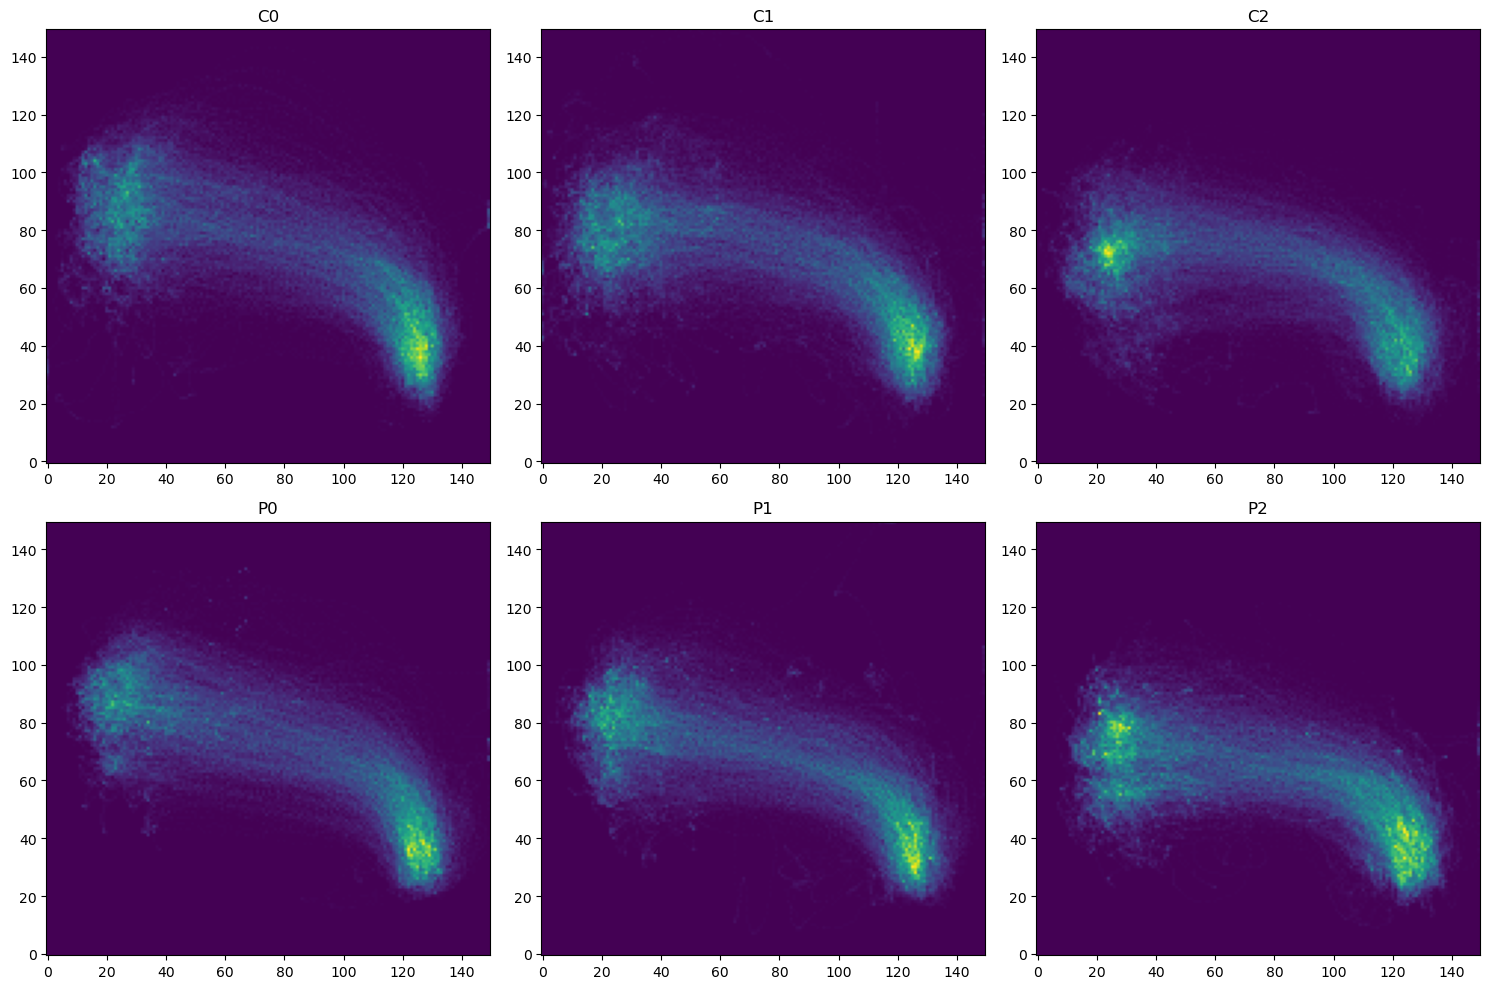

In [189]:
def front_heatmap(data, ax, e, c, pt):
    participants = list(map(lambda x: x[e][c], data))

    dfs = list(map(lambda x: rectify_unity(x), participants))
    all_values = pd.concat(dfs).sort_values(by=unified_delta_key)

    min_x = -1.75
    max_x = 0.25
    lateral = np.clip(list(all_values[pt + "_x"]), min_x, max_x)
    lateral = np.append(lateral, [min_x, max_x]) # Append limits as distinct values for matching dimensions

    min_y = -0.25
    max_y = 1.75
    vertical = np.clip(list(all_values[pt + "_y"]), min_y, max_y)
    vertical = np.append(vertical, [min_y, max_y]) # Append limits as distinct values for matching dimensions

    heatmap, xedges, yedges = np.histogram2d(lateral, vertical, bins=150)

    ax.title.set_text(c)
    ax.imshow(heatmap.T, origin='lower', cmap='viridis', aspect='auto')


fig, axs = plt.subplots(2, 3, figsize=(15, 10))
front_heatmap(data, axs[0,0], shovel, c_0, shovel_tip)
front_heatmap(data, axs[0,1], shovel, c_1, shovel_tip)
front_heatmap(data, axs[0,2], shovel, c_2, shovel_tip)
front_heatmap(data, axs[1,0], shovel, p_0, shovel_tip)
front_heatmap(data, axs[1,1], shovel, p_1, shovel_tip)
front_heatmap(data, axs[1,2], shovel, p_2, shovel_tip)

plt.tight_layout()
plt.show()

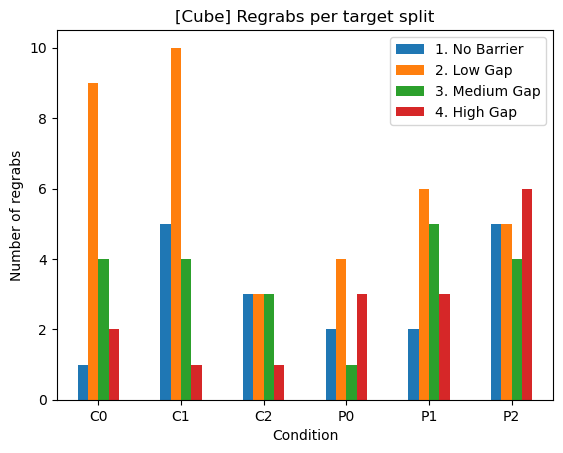

In [14]:
def single_grabcount_split(p):
    df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

    first = df[(df["cube_max_target_reached"] == 1)]
    second = df[(df["cube_max_target_reached"] == 2)]
    third = df[(df["cube_max_target_reached"] == 3)]
    fourth = df[(df["cube_max_target_reached"] == 4)]

    first_regrabs =first["grab_count"].max() - first["grab_count"].min()
    second_regrabs =second["grab_count"].max() - second["grab_count"].min()
    third_regrabs =third["grab_count"].max() - third["grab_count"].min()
    fourth_regrabs =fourth["grab_count"].max() - fourth["grab_count"].min()

    return [first_regrabs, second_regrabs, third_regrabs, fourth_regrabs]

def agg_grabcount_split(data, c):
    participants = list(map(lambda x: x[cube][c], data))

    splits = list(map(lambda x: single_grabcount_split(x), participants))
    
    first = list(map(lambda x: x[0],  splits))
    second = list(map(lambda x: x[1], splits))
    third = list(map(lambda x: x[2],  splits))
    fourth = list(map(lambda x: x[3], splits))
    
    return [np.sum(first), np.sum(second), np.sum(third), np.sum(fourth)]

condition_splits = list(map(lambda x: agg_grabcount_split(data, x), conditions))

df = pd.DataFrame(condition_splits, columns=["1. No Barrier", "2. Low Gap", "3. Medium Gap", "4. High Gap"], index = conditions)

df.plot(kind='bar', color=["tab:blue", "tab:orange", "tab:green", "tab:red"])

plt.title("[Cube] Regrabs per target split")
plt.xlabel("Condition")
plt.ylabel("Number of regrabs")

plt.gca().xaxis.set_tick_params(rotation=0)

plt.show()

In [ ]:
# end_effector = 'ee'
# primary_tracked = 'pt'
# primary_visible = 'pv'
# secondary_tracked = 'st'
# secondary_visible = 'sv'
# hmd = 'hmd'
# end_efector = 'ee'
# secondary_hand = 'st'
# primary_hand = 'pt'

# tracking_pts = [end_effector, primary_tracked, primary_visible, secondary_tracked, secondary_visible, hmd]
# pts = [hmd]

# def mirror_x(df, pt):
#     key = pt + '_x'
#     df[key] = df.apply(lambda x: -x[key] if x['primary_grab_hand'] == 'Left' else x[key], axis = 1)

# def rectify_unity (p):
#     df = trim_df(p[unity], min_ts = p[start_ts], max_ts = p[end_ts])

#     for pt in pts:
#         mirror_x(df, pt)

#     return df


# def top_scatter(data, ax, e, pts):
#     #sorted_conditions = [c_0, p_0, c_1, p_1, c_2, p_2]
#     #sorted_conditions = [c_2, c_1, c_0]
#     sorted_conditions = [p_2, p_1, p_0]
#     #sorted_colors = [colors[0], colors[3], colors[1], colors[4], colors[2], colors[5]]
#     #sorted_colors = [colors[2], colors[1], colors[0]]
#     sorted_colors = [colors[5], colors[4], colors[3]]
#     for i in range(len(sorted_conditions)):
#         c = sorted_conditions[i]
#         color = sorted_colors[i]
#         participants = list(map(lambda x: x[e][c], data))

#         dfs = list(map(lambda x: rectify_unity(x), participants))
#         all_values = pd.concat(dfs).sort_values(by=unified_delta_key)

#         for pt in pts:
#             lateral = list(all_values[pt + "_x"])
#             forward = list(all_values[pt + "_z"])
#             vertical = list(all_values[pt + "_y"])

#             ax.scatter(lateral, forward, color=color, alpha=0.02)

#         #ax.set_ylim([-0.5, 2])
#         #ax.set_xlim([-2.0, 0.5])

# fig, axs = plt.subplots(1, 1, figsize=(15, 15))
# top_scatter(data, axs, shovel, pts)

# plt.tight_layout()
# plt.show()